In [7]:
%reload_ext autoreload
%autoreload 2

import logging
logging.basicConfig(level=logging.INFO)

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np

import numpyro
import numpyro.distributions as dist
from numpyro import handlers
from einops import repeat

import matplotlib.pyplot as plt

from fpp.models.scd import dnds
from fpp.likelihoods.npll_jax import log_like_np
from fpp.utils.multi_corner import multi_corner

from fpp.models.np_model import NPModel
from fpp.utils.utils import jnp_trapezoid

# 1. Testing `numpyro` with a small model
We test the `numpyro` fitting pipeline using a small model to Fermi data. This will test that the code is working, and give us an rough estimate of the various template normalizations.

In [2]:
# The key function to modify is the model() function, which defines the forward probabilistic model.
# We will reuse te same class as in our fiducial fit, NPModel.

class NPModelSmall(NPModel):

    def __init__(self):
        super().__init__(
            n_exp=1, # single exposure region
            l_max=0, # no spherical harmonic modulation of pibrem
            diffuse_names=["ModelO"], # only Model O for pibrem and ics for now
        )

    def model(self, data=None, beta=1.):

        mu = jnp.zeros_like(data)

        #=== diffuse: pibrem, ics ===
        mu += numpyro.sample("S_pib", dist.Uniform(1e-3, 14)) * self.pib[0] # Specifies a random variable S_pib and adding it to mu, the diffuse portion of the expected counts.
        mu += numpyro.sample("S_ics", dist.Uniform(1e-3, 14)) * self.ics[0]

        #=== diffuse: isotropic, fermi bubble, (resolved) point sources ===
        mu += numpyro.sample("S_iso", dist.Uniform(1e-3, 5.)) * self.temp_iso
        mu += numpyro.sample("S_bub", dist.Uniform(1e-3, 5.)) * self.temp_bub
        mu += numpyro.sample("S_psc", dist.Uniform(1e-3, 5.)) * self.temp_psc

        #=== diffuse: gce (=nfw) ===
        S_nfw = numpyro.sample("S_nfw", dist.Uniform(1e-5, 4.))
        temp_nfw_poiss = self.nfw_temp_gen.get_NFW2_template(gamma=0.9) # This gamma value can be inferred. For now we fix it.
        temp_nfw_poiss /= jnp.mean(temp_nfw_poiss[~self.nm])
        mu += S_nfw * temp_nfw_poiss

        #=== point source: disk ===
        Sps_dsk = numpyro.sample("Sps_dsk", dist.Uniform(1e-5, 4.))
        temp_dsk_ps = self.dsk_temp_gen.get_template(zs=0.5, C=3)
        temp_dsk_ps /= jnp.mean(temp_dsk_ps[~self.nm])

        npt_compressed = jnp.array([temp_dsk_ps])
        theta = []
        s_arr = jnp.logspace(-1., 2., 1000)
        n1 = numpyro.sample(f'n1_dsk', dist.Uniform(4.0, 6.0))
        n2 = numpyro.sample(f'n2_dsk', dist.Uniform(0.5, 1.99))
        n3 = numpyro.sample(f'n3_dsk', dist.Uniform(-6., -5.))
        sb1 = numpyro.sample(f'sb1_dsk', dist.Uniform(5., 40.0))
        lambda_s = numpyro.sample(f'lambdas_dsk', dist.Uniform(0.1, 0.95))

        theta_tmp = jnp.array([1., n1, n2, n3, sb1, lambda_s * sb1])
        dnds_arr = dnds(s_arr, theta_tmp)
        A = Sps_dsk / jnp_trapezoid(s_arr * dnds_arr, s_arr)
        theta.append([A, n1, n2, n3, sb1, lambda_s * sb1])
        theta = jnp.array(theta)

        #=== point source: adjust with exposure regions ===
        # This can be ignored for now since we have only one exposure region.
        exp_lens = [len(self.expreg_indices[i]) for i in range(len(self.expreg_indices))]
        n_pad = exp_lens[0] - exp_lens[-1]

        expreg_indices = jnp.zeros_like(self.expreg_indices)
        expreg_indices = expreg_indices.at[:-1].set(self.expreg_indices[:-1])
        expreg_indices = expreg_indices.at[-1].set(jnp.pad(self.expreg_indices[-1], (0, n_pad)))

        log_like_np_exp_vmapped = jax.vmap(log_like_np, in_axes=(0, 0, 1, 0, None, None, None, None))

        mu_batch = mu[~self.mask_roi][jnp.array(expreg_indices)]
        npt_compressed_batch = npt_compressed[:, ~self.mask_roi][:, jnp.array(expreg_indices)]
        data_batch = data[~self.mask_roi][jnp.array(expreg_indices)]
        exposure_multiplier = self.exposure_means_list / self.exposure_mean

        theta = repeat(theta, "n_ps n_param -> n_exp n_ps n_param", n_exp=len(expreg_indices))
        theta = theta.at[:, :, 0].set(theta[:, :, 0] / exposure_multiplier[:, None])
        theta = theta.at[:, :, -1].set(theta[:, :, -1] * exposure_multiplier[:, None])
        theta = theta.at[:, :, -2].set(theta[:, :, -2] * exposure_multiplier[:, None])

        #=== compute likelihood ===
        with numpyro.plate("data", size=len(mu[~self.mask_roi]), dim=-1):

            log_like_exp = log_like_np_exp_vmapped(
                theta,
                mu_batch,
                npt_compressed_batch,
                data_batch,
                self.f_ary,
                self.df_rho_ary,
                self.k_max,
                len(expreg_indices[0]),
            )
            loglike = jnp.concatenate(log_like_exp)[:len(mu[~self.mask_roi])]

            with handlers.mask(mask=~jnp.logical_or(jnp.isinf(loglike), jnp.isnan(loglike))):
                with handlers.scale(scale=beta):
                    return numpyro.factor('log-likelihood', loglike)

In [3]:
m = NPModelSmall()

INFO:fpp.models.np_model:Number of pixels in ROI: 6839
INFO:fpp.models.np_model:Max photon count in ROI is 103
INFO:fpp.models.np_model:Using PSF correction: king
INFO:fpp.utils.psf_correction:Loading existing psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/src/fpp/utils/../../../data/psf_dir/Fermi_PSF_2GeV2_nside128.npy


In [4]:
# SVI fit
m.fit_svi(
    data=m.data, # Fermi data loaded by default, but fit_svi requires data to be passed in explicitly.
    guide='iaf', num_flows=3, hidden_dims=[16, 16], # SVI guide configuration: an (smaller) inverse autoregressive flow.
    lr=1e-4, n_steps=5000, # Depending on convergence, 5000-10000 steps should be sufficient.
)
samples_svi = m.get_svi_samples(num_samples=10000)

100%|██████████| 5000/5000 [13:43<00:00,  6.07it/s, init loss: 25530.1288, avg. loss [4751-5000]: 20091.1101, beta: 1.0000]


In [ ]:
# NUTS fit
mcmc = m.run_nuts(
    data=m.data, # Similarly, data must be passed in explicitly for NUTS as well.
    num_chains=4, num_warmup=500, # MCMC configuration: 4 chains with 500 warmup steps each.
    num_samples=2500, step_size=0.05, # We want 2500 * 4 = 10000 total samples.
)
samples_nuts = m.expand_samples(mcmc.get_samples())

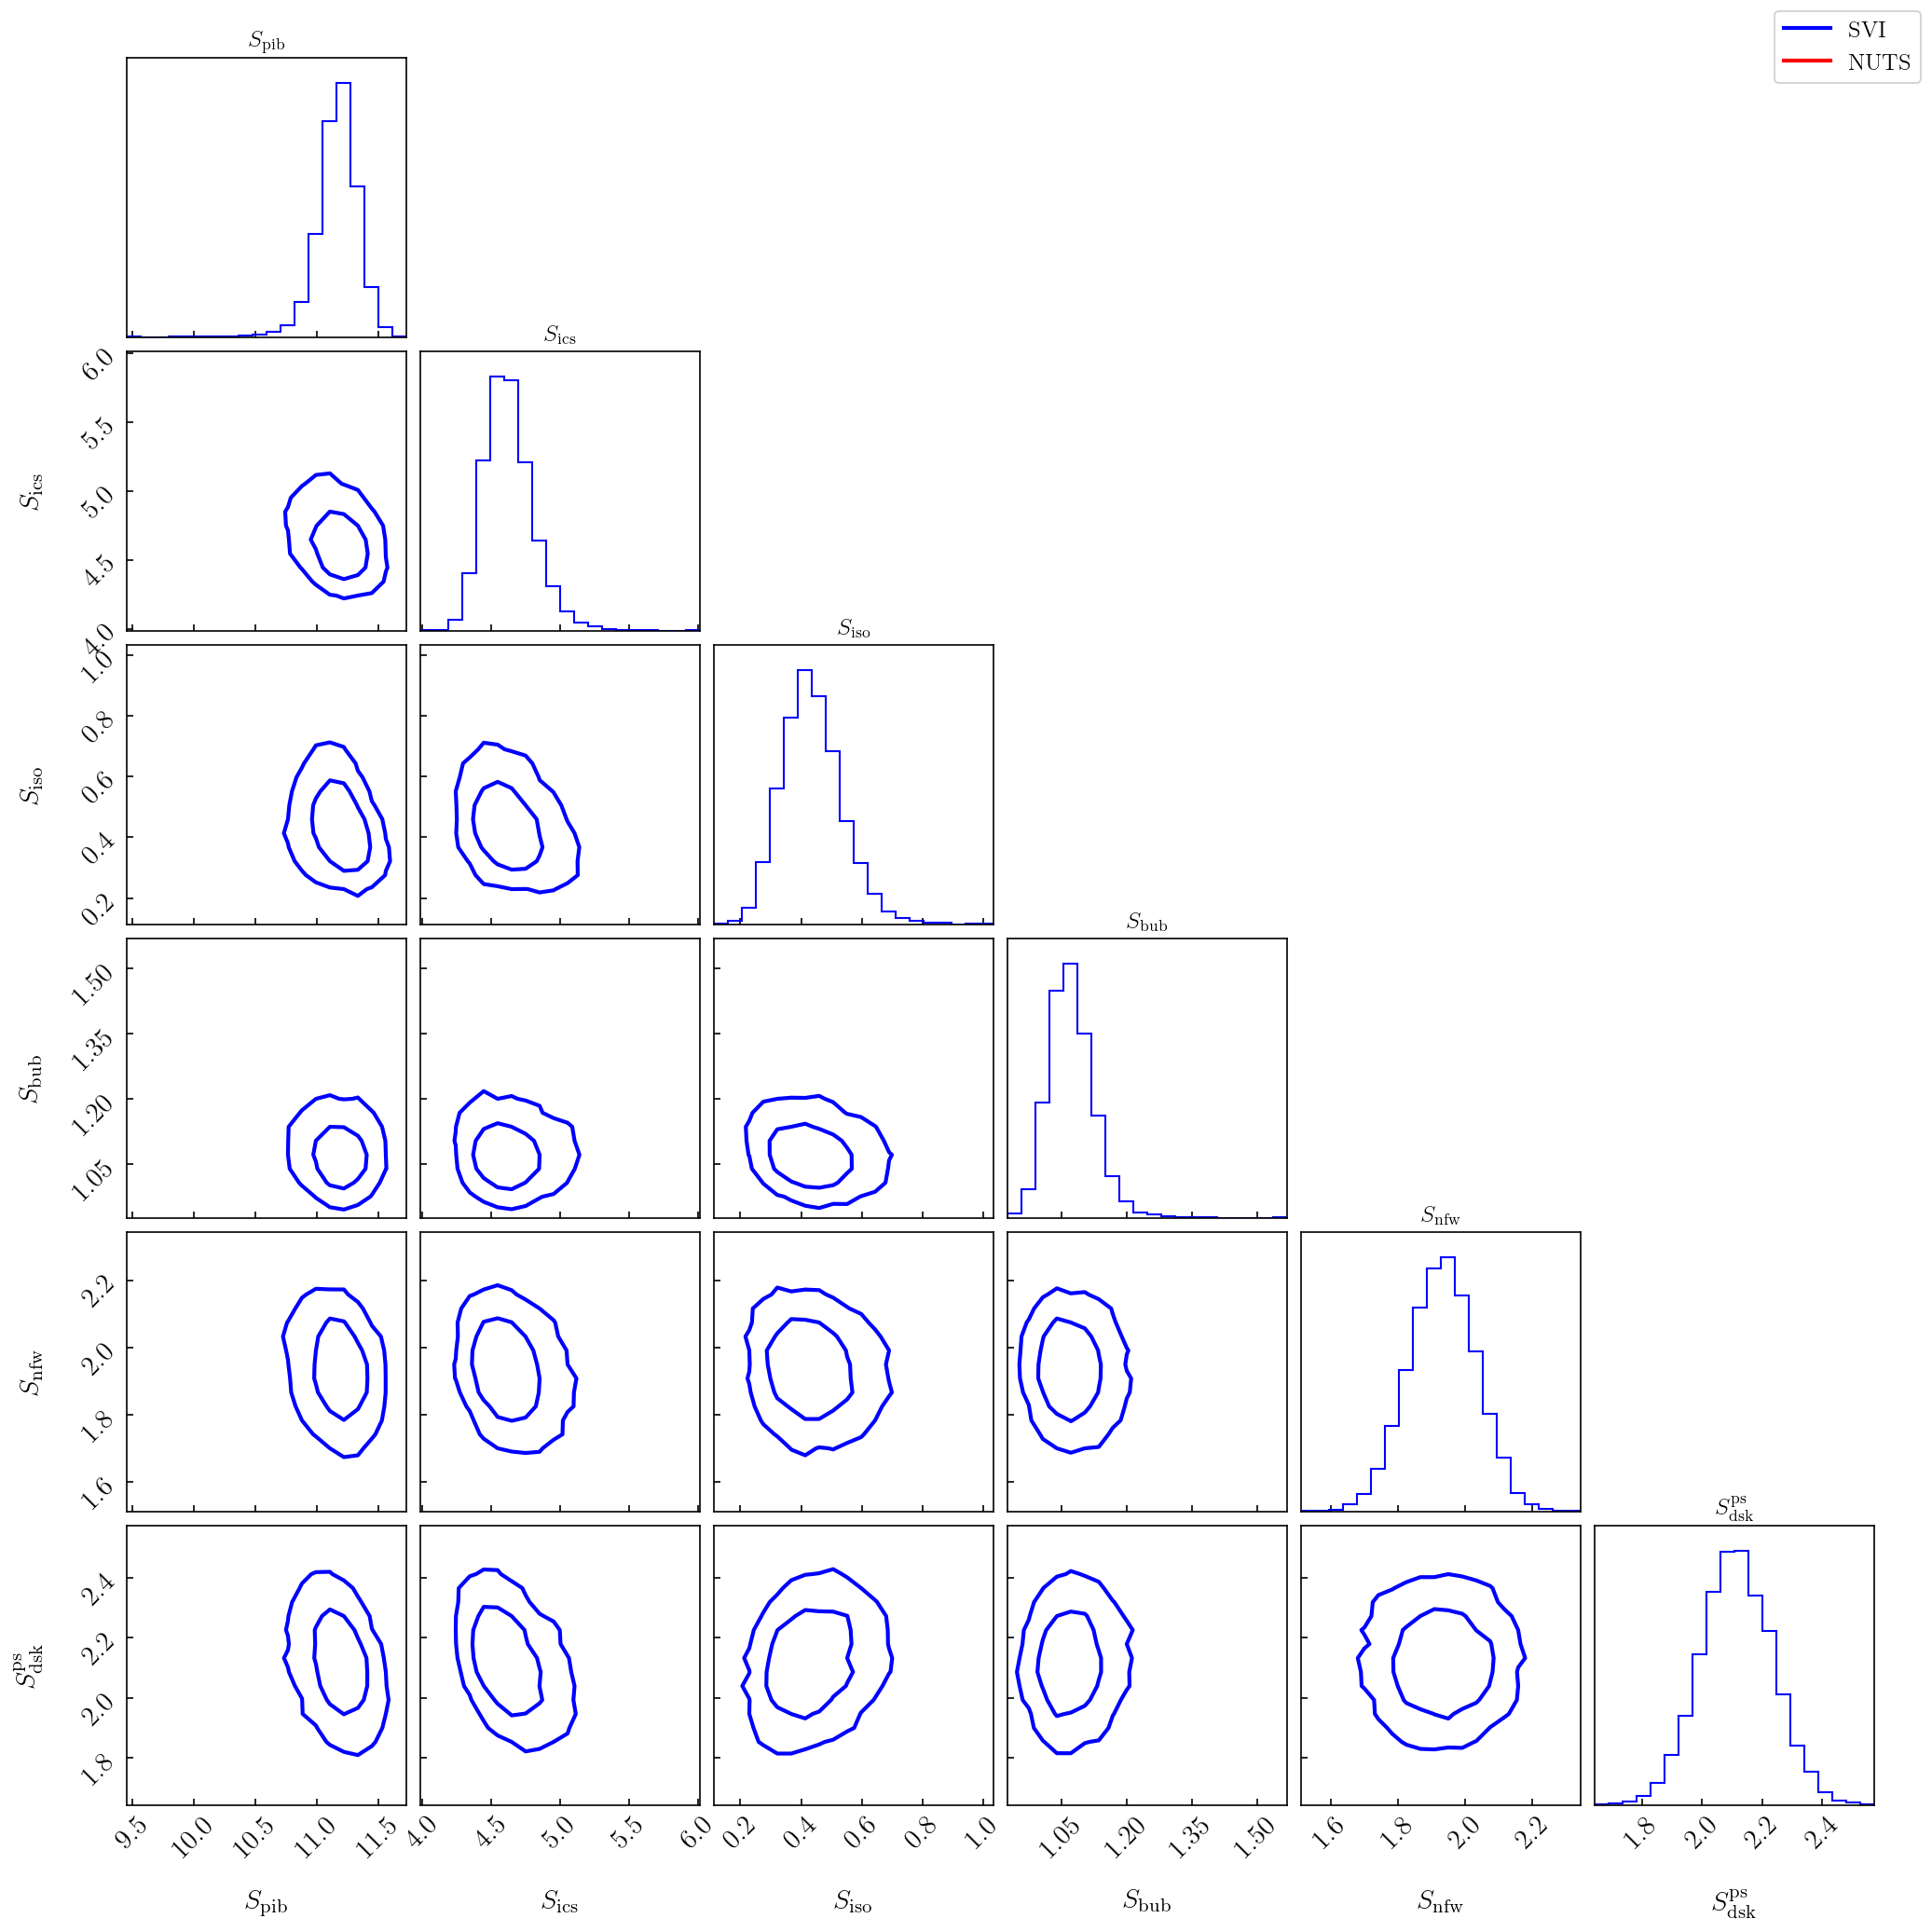

In [13]:
# Draw posteriors
plot_keys = ['S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_nfw', 'Sps_dsk']
def latex_label(l):
    l0, l1 = l.split('_')
    latex = 'S' if l0 == 'S' else r'S^\mathrm{ps}'
    latex += r'_\mathrm{' + l1 + '}'
    return '$' + latex + '$'

multi_corner(
    {'SVI': samples_svi},
    plot_keys,
    labels=[latex_label(k) for k in plot_keys],
    colors_dict={'SVI': 'b', 'NUTS': 'r'},
    labels_dict={'SVI': 'SVI', 'NUTS': 'NUTS'},
)

# Part 2: Isotropic Point Source Population

We add an isotropic PS population by inheriting from `NPModel` and overriding `model` only.
The isotropic template (`self.temp_iso`) is used as the spatial distribution for a new
non-Poissonian component, with its own SCD parameters.

In [ ]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np

import numpyro
import numpyro.distributions as dist
from numpyro import handlers
from einops import repeat

import matplotlib.pyplot as plt

from fpp.models.scd import dnds
from fpp.likelihoods.npll_jax import log_like_np
from fpp.utils.multi_corner import multi_corner

In [ ]:
class NPModelIso(NPModel):
    """NPModel + isotropic point source population."""

    def model(self, data=None, beta=1.):

        mu = jnp.zeros_like(data)

        #=== diffuse: pib with spherical harmonics, ics ===
        theta_pib = numpyro.sample("theta_pib", dist.Dirichlet(jnp.ones((self.n_dif,)) / self.n_dif))
        temp_pib = jnp.sum(theta_pib[:, None] * self.pib, 0)
        theta_ics = numpyro.sample("theta_ics", dist.Dirichlet(jnp.ones((self.n_dif,)) / self.n_dif))
        temp_ics = jnp.sum(theta_ics[:, None] * self.ics, 0)

        pib_modifier = jnp.zeros_like(data)
        for i in range(len(self.Ylm_temps)):
            Alm = numpyro.sample(f'Alm_{i}', dist.Uniform(-0.05, 0.05))
            pib_modifier += Alm * self.Ylm_temps[i]
        temp_pib = (1 + pib_modifier) * temp_pib
        temp_pib /= jnp.mean(temp_pib[~self.nm])

        mu += numpyro.sample("S_pib", dist.Uniform(1e-3, 14)) * temp_pib
        mu += numpyro.sample("S_ics", dist.Uniform(1e-3, 14)) * temp_ics

        #=== diffuse: isotropic, fermi bubble, (resolved) point sources ===
        mu += numpyro.sample("S_iso", dist.Uniform(1e-3, 5.)) * self.temp_iso
        mu += numpyro.sample("S_bub", dist.Uniform(1e-3, 5.)) * self.temp_bub
        mu += numpyro.sample("S_psc", dist.Uniform(1e-3, 5.)) * self.temp_psc

        #=== diffuse: gce (defined as bulge + nfw) ===
        S_gce = numpyro.sample("S_gce", dist.Uniform(1e-5, 4.))
        f_bulge_poiss = numpyro.sample("f_bulge_poiss", dist.Uniform(0., 1.))

        theta_blg_poiss = numpyro.sample("theta_bulge_poiss", dist.Dirichlet(jnp.ones((self.n_blg,)) / self.n_blg))
        temp_blg_poiss = jnp.sum(theta_blg_poiss[:, None] * self.blg_s, 0)

        temp_nfw_poiss = self.nfw_temp_gen.get_NFW2_template(gamma=numpyro.sample("gamma_poiss", dist.Uniform(0.2, 2.)))
        temp_nfw_poiss /= jnp.mean(temp_nfw_poiss[~self.nm])

        mu += S_gce * (f_bulge_poiss * temp_blg_poiss + (1 - f_bulge_poiss) * temp_nfw_poiss)

        #=== point source: gce (defined as bulge + nfw) ===
        Sps_gce = numpyro.sample("Sps_gce", dist.Uniform(1e-5, 8.))
        f_bulge_ps = numpyro.sample("f_bulge_ps", dist.Uniform(0., 1.))

        theta_blg_ps = numpyro.sample("theta_bulge_ps", dist.Dirichlet(jnp.ones((self.n_blg,)) / self.n_blg))
        temp_blg_ps = jnp.sum(theta_blg_ps[:, None] * self.blg_s, 0)

        temp_nfw_ps = self.nfw_temp_gen.get_NFW2_template(gamma=numpyro.sample("gamma_ps", dist.Uniform(0.2, 2.)))
        temp_nfw_ps /= jnp.mean(temp_nfw_ps[~self.nm])

        temp_gce_ps = f_bulge_ps * temp_blg_ps + (1 - f_bulge_ps) * temp_nfw_ps

        #=== point source: disk ===
        Sps_dsk = numpyro.sample("Sps_dsk", dist.Uniform(1e-5, 8.))
        zs = numpyro.sample("zs", dist.Uniform(0.1, 2.5))
        C = numpyro.sample("C", dist.Uniform(0.05, 8.))
        temp_dsk_ps = self.dsk_temp_gen.get_template(zs=zs, C=C)
        temp_dsk_ps /= jnp.mean(temp_dsk_ps[~self.nm])

        # NEW: isotropic point source population.
        # Uses self.temp_iso (already normalized) as the spatial template.
        Sps_iso = numpyro.sample("Sps_iso", dist.Uniform(1e-5, 8.))

        #=== point source: source count function and normalization ===
        # CHANGED: added Sps_iso and self.temp_iso to the PS lists
        Sps_list = [Sps_gce, Sps_dsk, Sps_iso]
        npt_compressed = jnp.array([temp_gce_ps, temp_dsk_ps, self.temp_iso])
        theta = []
        s_arr = jnp.logspace(-1., 2., 1000)
        # CHANGED: loop now includes "iso"
        for i, ps in enumerate(["gce", "dsk", "iso"]):
            n1 = numpyro.sample(f'n1_{ps}', dist.Uniform(4.0, 6.0))
            n2 = numpyro.sample(f'n2_{ps}', dist.Uniform(0.5, 1.99))
            n3 = numpyro.sample(f'n3_{ps}', dist.Uniform(-6., -5.))
            sb1 = numpyro.sample(f'sb1_{ps}', dist.Uniform(5., 40.0))
            lambda_s = numpyro.sample(f'lambdas_{ps}', dist.Uniform(0.1, 0.95))

            theta_tmp = jnp.array([1., n1, n2, n3, sb1, lambda_s * sb1])
            dnds_arr = dnds(s_arr, theta_tmp)
            A = Sps_list[i] / jnp.trapz(s_arr * dnds_arr, s_arr)
            theta.append([A, n1, n2, n3, sb1, lambda_s * sb1])
        theta = jnp.array(theta)

        #=== point source: adjust with exposure regions ===
        exp_lens = [len(self.expreg_indices[i]) for i in range(len(self.expreg_indices))]
        n_pad = exp_lens[0] - exp_lens[-1]

        expreg_indices = jnp.zeros_like(self.expreg_indices)
        expreg_indices = expreg_indices.at[:-1].set(self.expreg_indices[:-1])
        expreg_indices = expreg_indices.at[-1].set(jnp.pad(self.expreg_indices[-1], (0, n_pad)))

        log_like_np_exp_vmapped = jax.vmap(log_like_np, in_axes=(0, 0, 1, 0, None, None, None, None))

        mu_batch = mu[~self.mask_roi][jnp.array(expreg_indices)]
        npt_compressed_batch = npt_compressed[:, ~self.mask_roi][:, jnp.array(expreg_indices)]
        data_batch = data[~self.mask_roi][jnp.array(expreg_indices)]
        exposure_multiplier = self.exposure_means_list / self.exposure_mean

        theta = repeat(theta, "n_ps n_param -> n_exp n_ps n_param", n_exp=len(expreg_indices))
        theta = theta.at[:, :, 0].set(theta[:, :, 0] / exposure_multiplier[:, None])
        theta = theta.at[:, :, -1].set(theta[:, :, -1] * exposure_multiplier[:, None])
        theta = theta.at[:, :, -2].set(theta[:, :, -2] * exposure_multiplier[:, None])

        #=== compute likelihood ===
        with numpyro.plate("data", size=len(mu[~self.mask_roi]), dim=-1):

            log_like_exp = log_like_np_exp_vmapped(
                theta,
                mu_batch,
                npt_compressed_batch,
                data_batch,
                self.f_ary,
                self.df_rho_ary,
                self.k_max,
                len(expreg_indices[0]),
            )
            loglike = jnp.concatenate(log_like_exp)[:len(mu[~self.mask_roi])]

            with handlers.mask(mask=~jnp.logical_or(jnp.isinf(loglike), jnp.isnan(loglike))):
                with handlers.scale(scale=beta):
                    return numpyro.factor('log-likelihood', loglike)

In [ ]:
m2 = NPModelIso()

In [ ]:
# SVI fit
m2.fit_svi(
    n_steps=5000, data=m2.data, lr=1e-4,
    rng_key=jax.random.PRNGKey(42),
    guide='iaf', num_flows=4, hidden_dims=[64, 64],
    num_particles=8,
)
samples_iso_svi = m2.get_svi_samples(num_samples=10000)

In [ ]:
# NUTS fit
mcmc2 = m2.run_nuts(
    num_chains=4, num_warmup=500, num_samples=2500, step_size=0.05,
    data=m2.data,
    rng_key=jax.random.PRNGKey(0),
)
samples_iso_nuts = m2.expand_samples(mcmc2.get_samples())

In [ ]:
# Compare base model (NUTS) vs extended model (NUTS) on shared parameters
multi_corner(
    {'base': samples_nuts, 'iso': samples_iso_nuts},
    labels,
    colors_dict={'base': 'k', 'iso': 'b'},
    labels_dict={'base': 'Base', 'iso': '+ Iso PS'},
)

In [ ]:
# New parameters specific to the isotropic PS population
labels_iso = ['Sps_iso', 'n1_iso', 'n2_iso', 'n3_iso', 'sb1_iso', 'lambdas_iso']

fig, axs = plt.subplots(2, 3, figsize=(10, 5))
for ax, k in zip(axs.flat, labels_iso):
    ax.hist(np.array(samples_iso_nuts[k]), bins=40, density=True, color='b', alpha=0.5, label='NUTS')
    ax.hist(np.array(samples_iso_svi[k]), bins=40, density=True, color='r', alpha=0.5, label='SVI')
    ax.set(title=k)
axs[0, 0].legend()
plt.tight_layout()